#Names
Sanjana M-1RUA25SCS0087

Sanjana S-1RUA25SCS0088

Sanjay M-1RUA25SCS0089


#Flight Price Prediction

End to End analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv('/content/Clean_Dataset - Clean_Dataset.csv')
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26123 entries, 0 to 26122
Data columns (total 12 columns):
 #   Column     

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
26118,26118,Indigo,0.00E+00,Delhi,Early_Morning,one,Afternoon,Kolkata,Economy,6.25,35,6454
26119,26119,Indigo,0.00E+00,Delhi,Evening,one,Night,Kolkata,Economy,4.17,35,6020
26120,26120,Indigo,0.00E+00,Delhi,Evening,one,Late_Night,Kolkata,Economy,5.67,35,6052
26121,26121,Air_India,AI-877,Delhi,Morning,one,Afternoon,Kolkata,Economy,27.83,35,6113


In [ ]:
df.shape

(26123, 12)

Identifying Null Values

In [ ]:
df.isnull()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
26118,False,False,False,False,False,False,False,False,False,False,False,False
26119,False,False,False,False,False,False,False,False,False,False,False,False
26120,False,False,False,False,False,False,False,False,False,False,False,False
26121,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print("\nMissing Values Count:")
missing_counts = df.isnull().sum()
print(missing_counts)

print("\nMissing Values Percentage:")
print((missing_counts / len(df)) * 100)

cols_with_missing_values = missing_counts[missing_counts > 0].index.tolist()



Missing Values Count:
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Missing Values Percentage:
Unnamed: 0          0.0
airline             0.0
flight              0.0
source_city         0.0
departure_time      0.0
stops               0.0
arrival_time        0.0
destination_city    0.0
class               0.0
duration            0.0
days_left           0.0
price               0.0
dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26123 entries, 0 to 26122
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        26123 non-null  int64  
 1   airline           26123 non-null  object 
 2   flight            26123 non-null  object 
 3   source_city       26123 non-null  object 
 4   departure_time    26123 non-null  object 
 5   stops             26123 non-null  object 
 6   arrival_time      26123 non-null  object 
 7   destination_city  26123 non-null  object 
 8   class             26123 non-null  object 
 9   duration          26123 non-null  float64
 10  days_left         26123 non-null  int64  
 11  price             26123 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 2.4+ MB


 4. Handling Null Values

In [ ]:
import numpy as np

if cols_with_missing_values:
    print("\nCreating indicator columns for missing values before imputation:")
    for col in cols_with_missing_values:
        df[f'{col}_was_null'] = df[col].isnull()
        print(f"  - Created '{col}_was_null' column.")
else:
    print("\nNo columns with missing values found to create indicator columns.")

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("\nImputing missing values:")

for col in (set(num_cols) & set(cols_with_missing_values)):
    df[col] = df[col].fillna(df[col].median())
    print(f"  - Imputed numeric column '{col}' with median.")

for col in (set(cat_cols) & set(cols_with_missing_values)):
    df[col] = df[col].fillna(df[col].mode()[0])
    print(f"  - Imputed categorical column '{col}' with mode.")

print("\nAfter Handling Missing Values:")
print((df.isnull().sum() / len(df)) * 100)
df.mean(numeric_only=True)
df.median(numeric_only=True)



No columns with missing values found to create indicator columns.

Imputing missing values:

After Handling Missing Values:
Unnamed: 0          0.0
airline             0.0
flight              0.0
source_city         0.0
departure_time      0.0
stops               0.0
arrival_time        0.0
destination_city    0.0
class               0.0
duration            0.0
days_left           0.0
price               0.0
dtype: float64


,0
Unnamed: 0,13061.0
duration,8.5
days_left,24.0
price,5496.0


In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
26118,26118,Indigo,0.00E+00,Delhi,Early_Morning,one,Afternoon,Kolkata,Economy,6.25,35,6454
26119,26119,Indigo,0.00E+00,Delhi,Evening,one,Night,Kolkata,Economy,4.17,35,6020
26120,26120,Indigo,0.00E+00,Delhi,Evening,one,Late_Night,Kolkata,Economy,5.67,35,6052
26121,26121,Air_India,AI-877,Delhi,Morning,one,Afternoon,Kolkata,Economy,27.83,35,6113


In [ ]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,26123.000000,26123.000000,26123.000000,26123.000000
mean,13061.000000,10.268382,24.271255,6484.565747
std,7541.204877,7.006340,13.208782,3802.162435
min,0.000000,2.000000,1.000000,2281.000000
25%,6530.500000,5.170000,13.000000,4019.000000
50%,13061.000000,8.500000,24.000000,5496.000000
75%,19591.500000,13.830000,34.000000,7425.000000
max,26122.000000,36.920000,49.000000,32999.000000


Finding Duplicates

In [ ]:
print("\nDuplicates:", df.duplicated().sum())
df.shape
df = df.drop_duplicates()


Duplicates: 0


7. Outlier Detection (IQR)

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
26118,26118,Indigo,0.00E+00,Delhi,Early_Morning,one,Afternoon,Kolkata,Economy,6.25,35,6454
26119,26119,Indigo,0.00E+00,Delhi,Evening,one,Night,Kolkata,Economy,4.17,35,6020
26120,26120,Indigo,0.00E+00,Delhi,Evening,one,Late_Night,Kolkata,Economy,5.67,35,6052
26121,26121,Air_India,AI-877,Delhi,Morning,one,Afternoon,Kolkata,Economy,27.83,35,6113


In [ ]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound))
print("\nOutliers Detected:")
print(outliers.sum())


Outliers Detected:
Unnamed: 0       0
duration       588
days_left        0
price         2218
dtype: int64


 8. Categorical Encoding

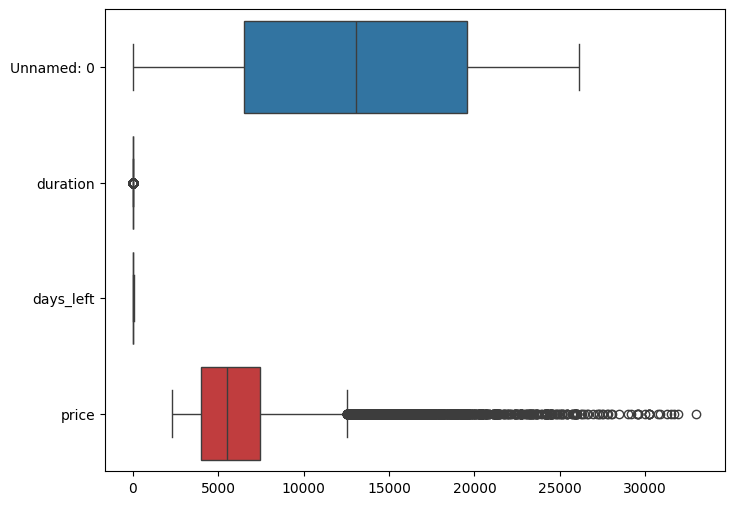

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, orient='h')
plt.show()

In [ ]:
le = LabelEncoder()
df['stops'] = le.fit_transform(df['stops'])

df_encoded = pd.get_dummies(df, columns=['stops'])
print(df_encoded.head())


   Unnamed: 0   airline   flight source_city  departure_time   arrival_time  \
0           0  SpiceJet  SG-8709       Delhi               2          Night   
1           1  SpiceJet  SG-8157       Delhi               1        Morning   
2           2   AirAsia   I5-764       Delhi               1  Early_Morning   
3           3   Vistara   UK-995       Delhi               4      Afternoon   
4           4   Vistara   UK-963       Delhi               4        Morning   

  destination_city    class  duration  days_left  price  stops_0  stops_1  \
0           Mumbai  Economy -1.155887  -1.761835   5953    False    False   
1           Mumbai  Economy -1.133050  -1.761835   5953    False    False   
2           Mumbai  Economy -1.155887  -1.761835   5956    False    False   
3           Mumbai  Economy -1.144469  -1.761835   5955    False    False   
4           Mumbai  Economy -1.133050  -1.761835   5955    False    False   

   stops_2  
0     True  
1     True  
2     True  
3     True

9.  Scaling Techniques

In [ ]:
# This line is commented out because the DataFrame already has no missing values (as confirmed by previous steps).
# Also, attempting to calculate the median for categorical columns is not a valid operation.
# df[['airline','flight','source_city','departure_time','stops','arrival_time','destination_city','class','duration','days_left','price']] = df[['airline','flight','source_city','departure_time','stops','arrival_time','destination_city','class','duration','days_left','price'']].fillna(df[['airline','flight','source_city','departure_time','stops','arrival_time','destination_city','class','duration','days_left','price']].median())

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Identify the numerical columns to scale
# For the 'Clean_Dataset', 'duration' and 'days_left' are the primary numerical features.
numerical_cols = ['duration', 'days_left']

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Apply scaling to the dataset
# This replaces the original values with their scaled (Z-score) versions
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display the scaled values
print(df[numerical_cols].head())

   duration  days_left
0 -1.155887  -1.761835
1 -1.133050  -1.761835
2 -1.155887  -1.761835
3 -1.144469  -1.761835
4 -1.133050  -1.761835


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, Normalizer

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Identify the numerical columns to scale
# For the 'Clean_Dataset', 'duration' and 'days_left' are the primary numerical features.
numerical_cols = ['duration', 'days_left']

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Apply scaling to the dataset
# This replaces the original values with their scaled (Z-score) versions
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display the scaled values
print(df[numerical_cols].head())

   duration  days_left
0 -1.155887  -1.761835
1 -1.133050  -1.761835
2 -1.155887  -1.761835
3 -1.144469  -1.761835
4 -1.133050  -1.761835


10. Data Visualization

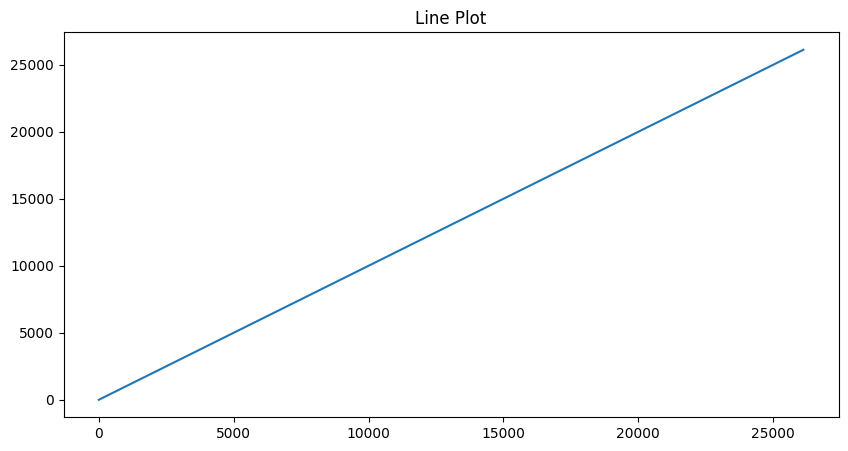

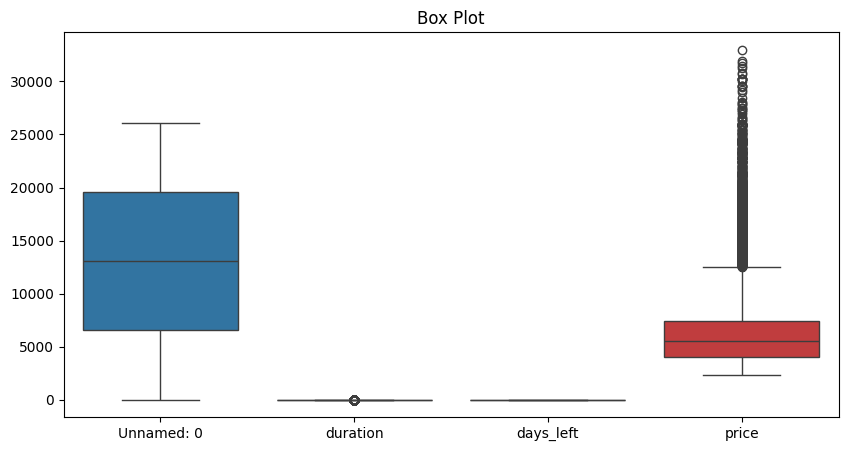

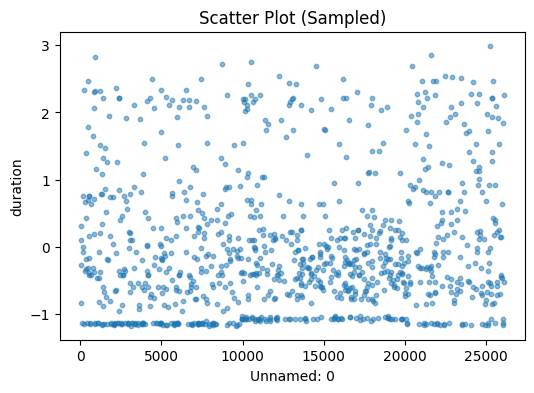

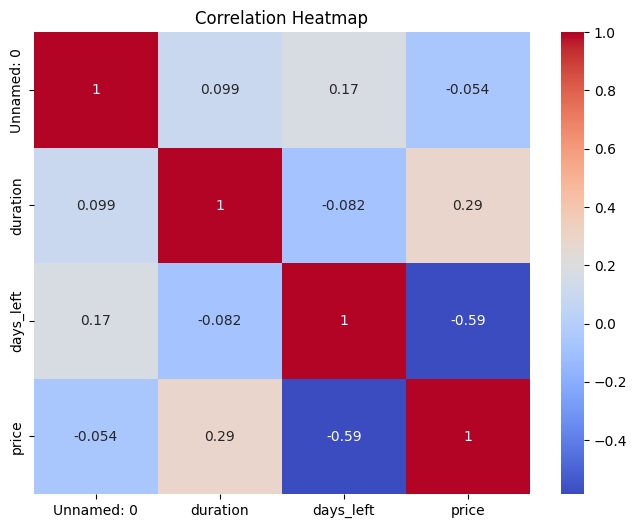

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df[num_cols[0]])
plt.title("Line Plot")
plt.show()

# Box Plot
plt.figure(figsize=(10,5))
sns.boxplot(data=df[num_cols])
plt.title("Box Plot")
plt.show()

#Scatter Plot
if len(num_cols) >= 2:
    sample_df = df.sample(1000)

    plt.figure(figsize=(6,4))
    plt.scatter(sample_df[num_cols[0]], sample_df[num_cols[1]],
                s=10, alpha=0.5)

    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.title("Scatter Plot (Sampled)")
    plt.show()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

11. Grouping & Aggregation

In [ ]:
if len(cat_cols) > 0:
    # Select only numeric columns for aggregation
    numeric_df = df.select_dtypes(include=np.number)

    # Group by the first categorical column and calculate the mean of numeric columns
    agg_df = numeric_df.groupby(df[cat_cols[0]]).mean()

    print("\nGrouped Data:")
    print(agg_df.head())


Grouped Data:
             Unnamed: 0  departure_time  duration  days_left        price
airline                                                                  
AirAsia    14561.244469        1.819322 -0.166229   0.138949  4852.870944
Air_India  12633.132319        2.416527  0.654955  -0.048766  7332.049515
GO_FIRST   12904.634921        2.027530 -0.372438   0.072973  5884.245288
Indigo     13811.099468        2.178878 -0.653726  -0.016461  5703.835653
SpiceJet   13317.053451        2.113667  0.114994  -0.099933  6023.309202


Matplot lib

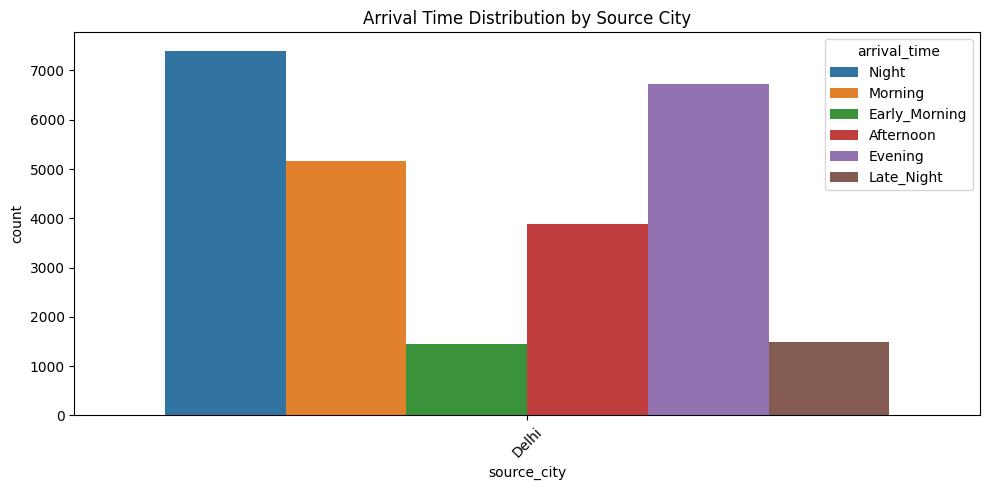

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(x='source_city', hue='arrival_time', data=df)

plt.xticks(rotation=45)
plt.title('Arrival Time Distribution by Source City')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

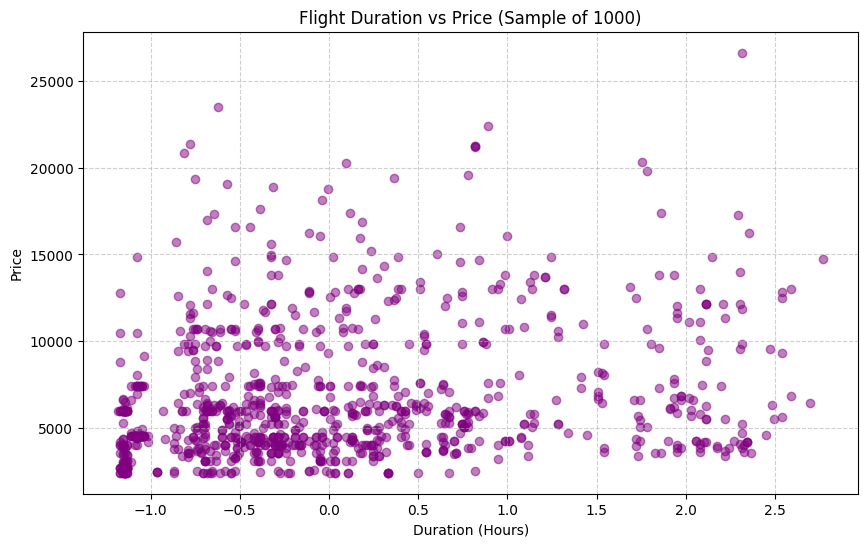

In [ ]:
import matplotlib.pyplot as plt
sample_df = df.sample(n=1000, random_state=1)
plt.figure(figsize=(10, 6))
plt.scatter(sample_df['duration'], sample_df['price'], alpha=0.5, c='purple')
plt.title('Flight Duration vs Price (Sample of 1000)')
plt.xlabel('Duration (Hours)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('duration_vs_price.png')

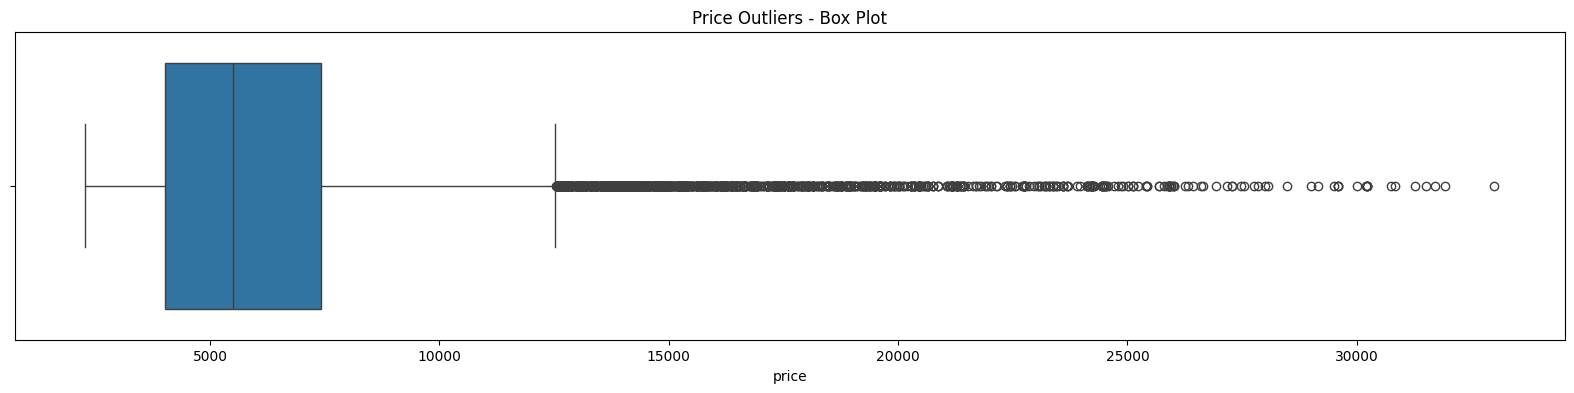

In [ ]:
plt.figure(figsize=(20, 4))
#plt.subplot(2, 2, 4)
sns.boxplot(x=df['price'])
plt.title('Price Outliers - Box Plot')
plt.show()

Seaborn Visualizations

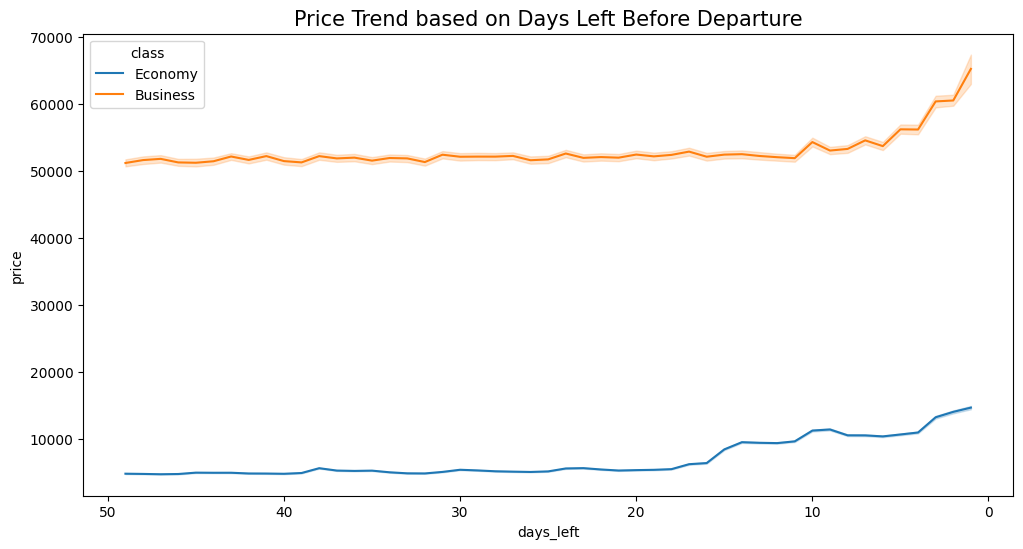

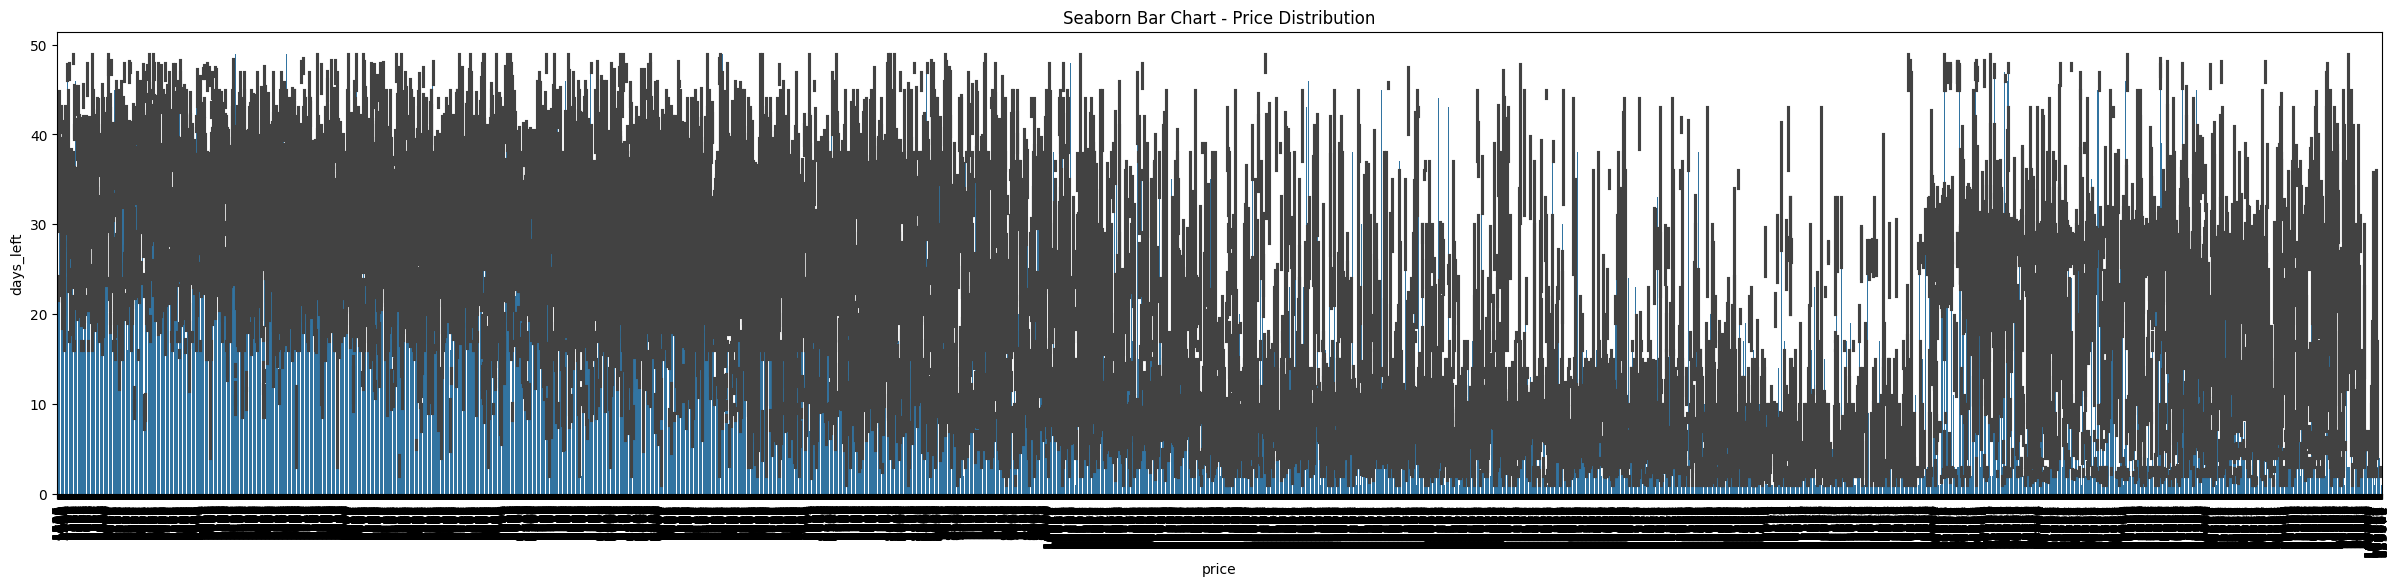

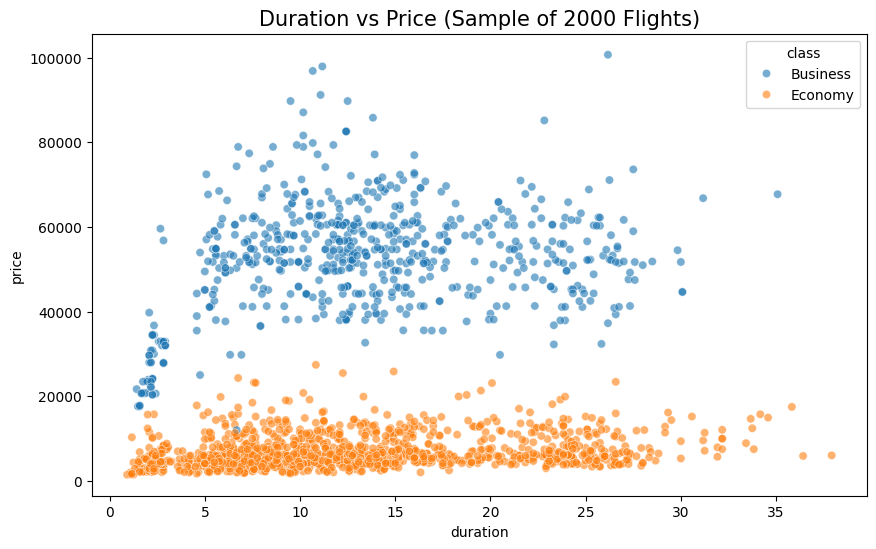

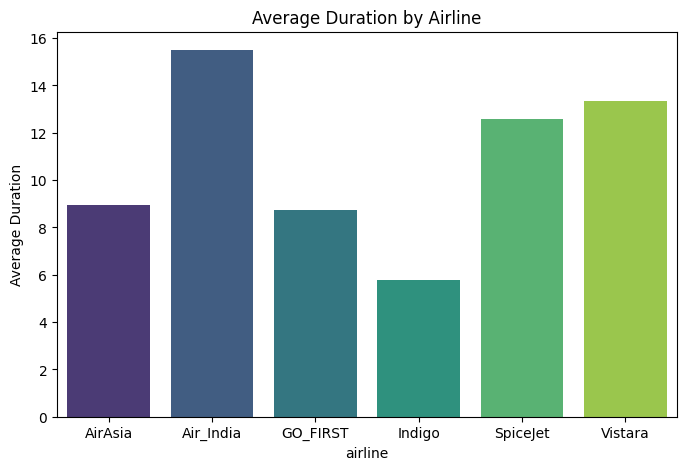

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd


df = pd.read_csv('/content/Clean_Dataset - Clean_Dataset.csv')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='days_left', y='price', hue='class')
plt.title('Price Trend based on Days Left Before Departure', fontsize=15)
plt.gca().invert_xaxis()
plt.savefig('seaborn_lineplot_days.png')

plt.figure(figsize=(30, 6))
sns.barplot(x=df['price'], y=df['days_left'])
plt.xticks(rotation=90)
plt.title('Seaborn Bar Chart - Price Distribution')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='duration', y='price', hue='class', alpha=0.6)
plt.title('Duration vs Price (Sample of 2000 Flights)', fontsize=15)
plt.show()

# Recreate agg_df within this cell using the reloaded df
# This agg_df will contain the mean duration per airline from the unscaled data
agg_df = df.groupby('airline')['duration'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='airline', y='duration', data=agg_df, hue='airline', legend=False, palette='viridis')
plt.title('Average Duration by Airline')
plt.ylabel('Average Duration')
plt.show()

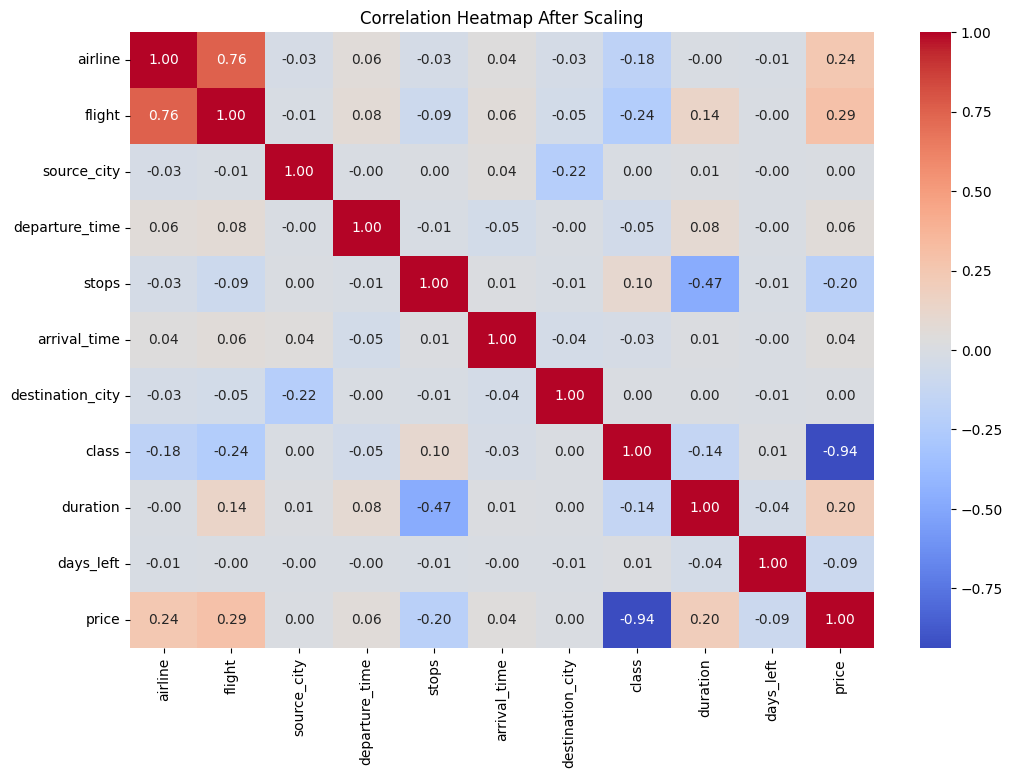

In [ ]:
df = pd.read_csv('Clean_Dataset - Clean_Dataset.csv')
df = df.drop(columns=['Unnamed: 0'])


le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()
num_cols = ['duration', 'days_left', 'price']

df[num_cols] = scaler.fit_transform(df[num_cols])


corr = df.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap After Scaling')
plt.show()

 12. Save Cleaned Dataset

In [ ]:
df.to_csv('Cleaned_Output.csv', index=False)

print("\n✅ Data Analysis Completed Successfully!")


✅ Data Analysis Completed Successfully!


# Introduction
#**Problem Statement**

In today’s aviation industry, flight ticket prices vary significantly due to multiple influencing factors such as airline type, class of travel, number of stops, duration, and booking timing. Understanding these variations is essential for both airlines and passengers. The main problem addressed in this analysis is to identify the key factors that affect flight prices and to uncover hidden patterns in the dataset that explain pricing behavior.


#**Objectives**

The main objective is to perform an end-to-end analysis of the flight dataset.

Key goals include:

Data cleaning and preprocessing

Identifying missing values and duplicates

Detecting outliers

Applying encoding and scaling techniques

Analyzing relationships between variables

Generating insights for decision-making

#**Key Findings**
Columns like :Airlines,Price,Days_left,Stops,Class and Duration


The dataset contains 26,123 rows and 12 columns, and it is clean with no missing or duplicate values.

**observations**

*Outliers detected:
Duration → 588 values
Price → 2218 values

*Airline impact:
Air India → higher average prices
Indigo, AirAsia → lower prices

*Class impact:
Business class tickets are much more expensive

*Days left vs price:
Prices increase as departure date approaches

*Stops vs price:
More stops → lower price but longer duration

*Duration vs price:
Longer flights generally cost more

#**Data Analysis**
**Data Cleaning**

The dataset is already clean:
No missing values

No duplicates

**Data Types**
Categorical: airline, city, class, etc.

Numerical: duration, days_left, price

**Outlier Detection**
Used IQR method

Significant outliers found in price and duration

 **Encoding**
Label Encoding for stops

One-Hot Encoding for categorical features

**Feature Scaling**
StandardScaler applied on:
Duration
Days_left

**Visualization Insights**
Line plot → price trends

Box plot → outliers in price

Scatter plot → duration vs price relationship

Heatmap → correlation between variables

**Grouping & Aggregation**
Average price differs across airlines

Premium airlines show higher fares

#**Conclusion**
Flight pricing depends on multiple key factors:

Airline

Travel class

Duration

Booking time



The dataset is well-prepared and suitable for:

Further analysis

Machine learning models



Clear trends observed:

Price increases when days left decreases

Longer duration leads to higher prices

Business class significantly increases cost



#**Suggestions**
**Data Suggestions**


Handle outliers for better accuracy

Remove unnecessary column






**Business Suggestions**

Airlines:

Use dynamic pricing

Offer early booking discounts



Customers:

Book tickets early

Choose flights based on cost vs convenience





